# Exploratory Data Analysis (EDA) & Data Cleaning
**Tujuan:** Memeriksa kesehatan data, menangani nilai kosong (*null*), dan membuat kolom baru untuk analisis.

In [ ]:
import numpy as np
import pandas as pd

# Link repo
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# Cek 5 baris pertama data
df.head()

### 🔍 1. Pemeriksaan Kesehatan Data (Data Health Check)
Sebelum melakukan analisis, kita harus mengecek apakah ada nilai yang kosong (*missing values*) dan memastikan tipe datanya sudah sesuai.

In [ ]:
missing_data = df.isnull().sum()
print("kolom dengan nilai kosong")
print(missing_data[missing_data > 0])


# Hasil Temuan & Kesimpulan Missing Values
* **children:** 4 data kosong (paling sedikit)
* **country:** 488 data kosong
* **agent:** 16.340 data kosong
* **company:** 112.593 data kosong (paling banyak)

> **Kesimpulan:** Terlihat perbedaan angka yang sangat signifikan dari kolom `children` hingga `company`. Nilai kosong terkecil ada pada kolom `children`, sedangkan nilai kosong terbanyak ada di kolom `company`.

In [ ]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("unknown")
df["company"] = df["company"].fillna(0)
df["agent"] = df["agent"].fillna(0)

print("sisa data kosong:", df.isnull().sum().sum())



In [ ]:
df["total_stay"]= df["stays_in_weekend_nights"] + df['stays_in_week_nights']
df["total_guests"]= df["adults"] + df["children"]+ df["babies"]

df[["total_stay", "total_guests"]].head()

### 🚨 4. Penanganan Data Anomali (Filtering Outliers)
Pemesanan dengan `Total_guests == 0` dianggap sebagai data tidak valid (anomali) dan harus dihapus dari dataset.

In [ ]:
anomali_tamu = len(df[df["Total_guests"]==0])
print("jumlah data anomali (0 tamu):", anomali_tamu)

df= df[df["Total_guests"]> 0]

print("jumlah baris data setelah cleaning", len(df))

> **Catatan Anomali:** Terdeteksi 180 transaksi pemesanan dengan 0 tamu (anomali). Data tersebut telah dihapus sehingga total sampel analisis yang valid menjadi 119.210 baris.

In [ ]:
# Mengubah tipe data float menjadi integer
df["children"] = df["children"].astype(int)
df["Total_guests"] = df["Total_guests"].astype(int)

# Cek tipe data hasil perubahan
print(df[["children", "Total_guests"]].dtypes)

# 📊 Hari 9: Agregasi Data & Analisis Bisnis dengan Pandas
**Tujuan:** Menganalisis metrik utama bisnis seperti tingkat pembatalan (*cancellation rate*) dan rata-rata harga kamar (*Average Daily Rate / ADR*) berdasarkan segmen hotel.

---
## 🏨 1. Perbandingan Cancellation Rate: City Hotel vs Resort Hotel
Kita ingin mengetahui hotel mana yang memiliki tingkat pembatalan paling tinggi.

In [ ]:
# Menganalisis pembatalan berdasarkan jenis hotel
hotel_summary = (
    df.groupby("hotel")
    .agg(
        total_pesanan=("is_canceled", "count"),
        total_dibatalkan=("is_canceled", "sum"),
        cancelation_rate=("is_canceled", "mean"),
        )
    .reset_index()
)

# Mengubah cancellation_rate menjadi persentase (%)
hotel_summary["cancellation_rate"] = (
    hotel_summary["cancellation_rate"] * 100
). round(2)

hotel_summary

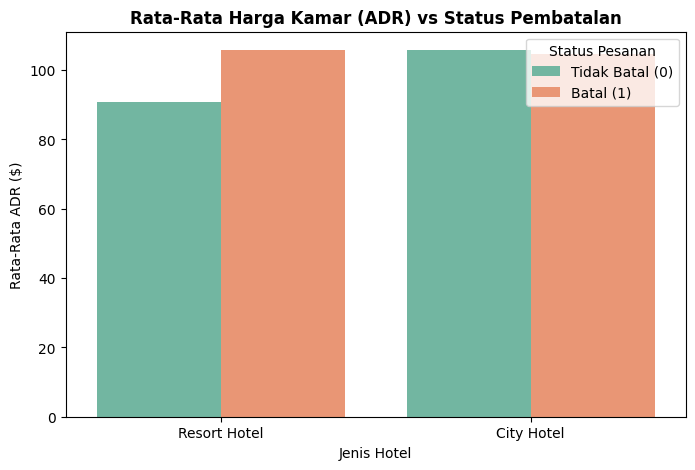

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Membuat grafik batang visual
sns.barplot(
    data=df,
    x="hotel",
    y="adr",
    hue="is_canceled",
    palette="Set2",
    errorbar=None,
)

plt.title(
    "Rata-Rata Harga Kamar (ADR) vs Status Pembatalan",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Jenis Hotel")
plt.ylabel("Rata-Rata ADR ($)")
plt.legend(title="Status Pesanan", labels=["Tidak Batal (0)", "Batal (1)"])

plt.show()

> **Insight Bisnis:** Pada kedua jenis hotel, pesanan yang akhirnya dibatalkan memiliki rata-rata harga kamar (ADR) yang lebih tinggi. Hal ini mengindikasikan bahwa **harga kamar yang mahal menjadi salah satu pemicu utama tamu membatalkan pesanan** (mencari alternatif yang lebih murah).

# 📈 Hari 10: Visualisasi Segmentasi Pasar & Perilaku Pelanggan
**Tujuan:** Mengidentifikasi segmen pasar (*Market Segment*) yang paling dominan serta tingkat pembatalannya.

---
## 🎯 1. Distribusi Pemesanan Berdasarkan Market Segment
Kita akan melihat saluran mana (seperti Online TA, Offline TA/TO, Direct, Groups) yang paling banyak menyumbang pemesanan.

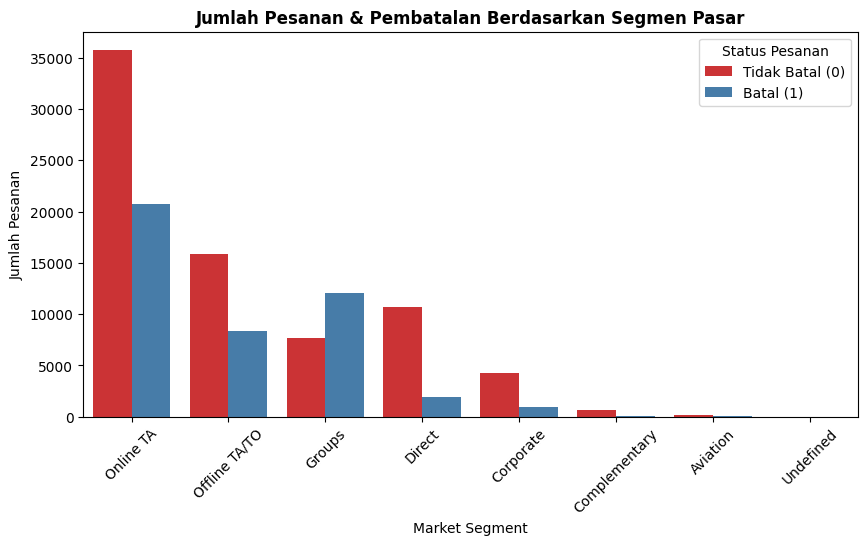

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Memvisualisasikan jumlah pesanan berdasarkan market_segment dan status pembatalan
sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled",
    palette="Set1",
    order=df["market_segment"].value_counts().index,
)

plt.title(
    "Jumlah Pesanan & Pembatalan Berdasarkan Segmen Pasar",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Market Segment")
plt.ylabel("Jumlah Pesanan")
plt.legend(title="Status Pesanan", labels=["Tidak Batal (0)", "Batal (1)"])
plt.xticks(rotation=45)

plt.show()

---
## 💳 1. Pengaruh Kebijakan Deposit Terhadap Pembatalan
Kita menganalisis proporsi pembatalan berdasarkan 3 tipe deposit: `No Deposit`, `Non Refund`, dan `Refundable`.

/tmp/ipykernel_1236/1085283198.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Tanpa Deposit", "Non-Refundable", "Refundable"])


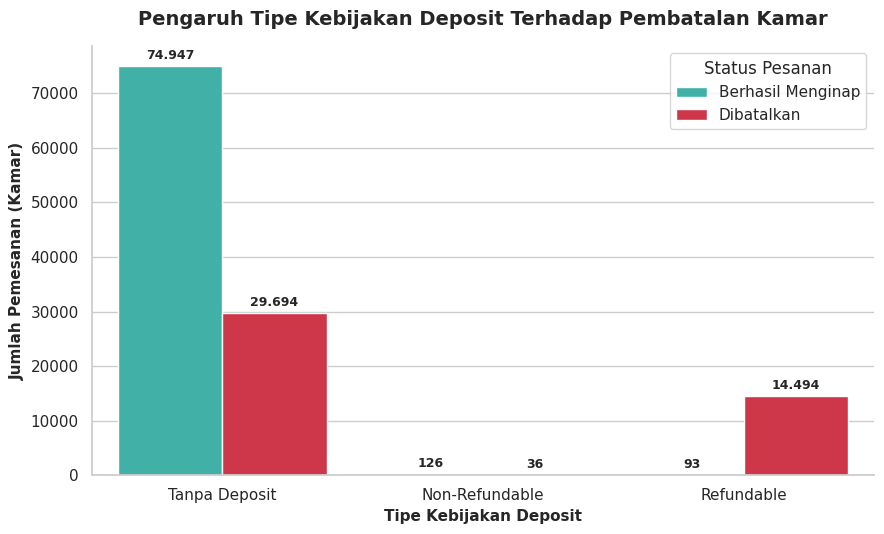

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5.5))

# Palette warna: Hijau = Menginap, Merah = Batal
colors = {0: "#2ec4b6", 1: "#e71d36"}

ax = sns.countplot(data=df, x="deposit_type", hue="is_canceled", palette=colors)

plt.title(
    "Pengaruh Tipe Kebijakan Deposit Terhadap Pembatalan Kamar",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Tipe Kebijakan Deposit", fontsize=11, fontweight="bold")
plt.ylabel("Jumlah Pemesanan (Kamar)", fontsize=11, fontweight="bold")

ax.set_xticklabels(["Tanpa Deposit", "Non-Refundable", "Refundable"])

plt.legend(
    title="Status Pesanan",
    labels=["Berhasil Menginap", "Dibatalkan"],
    frameon=True,
)

# Perbaikan label angka pasti dengan format ribuan
for container in ax.containers:
    labels = [
        f"{int(v):,}".replace(",", ".") if v > 0 else "0"
        for v in container.datavalues
    ]
    ax.bar_label(
        container, labels=labels, padding=3, fontsize=9, fontweight="bold"
    )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

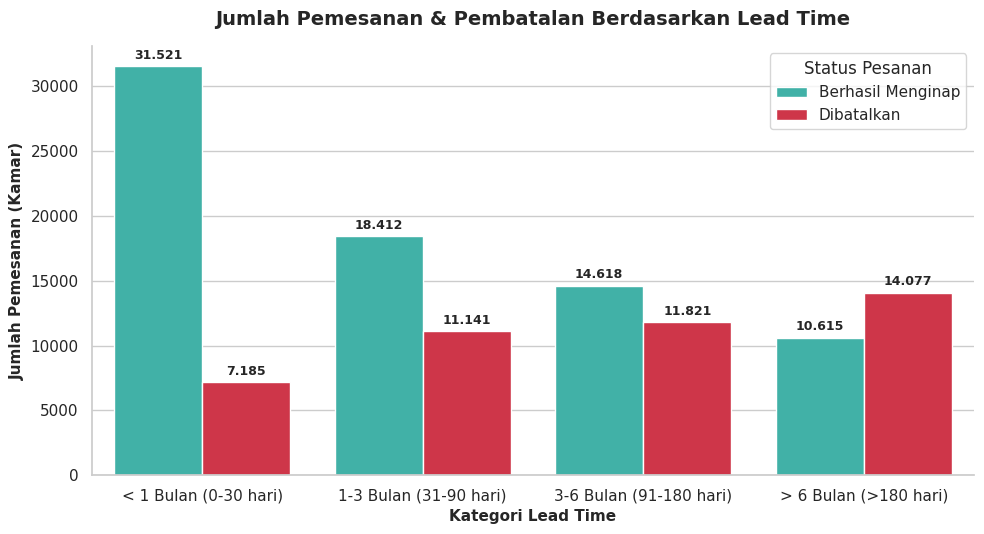

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Mengelompokkan lead_time ke dalam kategori (binning)
bins = [-1, 30, 90, 180, 999]
labels = [
    "< 1 Bulan (0-30 hari)",
    "1-3 Bulan (31-90 hari)",
    "3-6 Bulan (91-180 hari)",
    "> 6 Bulan (>180 hari)",
]
df["lead_time_group"] = pd.cut(df["lead_time"], bins=bins, labels=labels)

# 2. Membuat Grafik Batang
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5.5))

colors = {0: "#2ec4b6", 1: "#e71d36"}

ax = sns.countplot(
    data=df, x="lead_time_group", hue="is_canceled", palette=colors
)

plt.title(
    "Jumlah Pemesanan & Pembatalan Berdasarkan Lead Time",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Kategori Lead Time", fontsize=11, fontweight="bold")
plt.ylabel("Jumlah Pemesanan (Kamar)", fontsize=11, fontweight="bold")
plt.legend(
    title="Status Pesanan",
    labels=["Berhasil Menginap", "Dibatalkan"],
    frameon=True,
)

# Menambahkan angka pasti di atas setiap batang
for container in ax.containers:
    labels_val = [
        f"{int(v):,}".replace(",", ".") if v > 0 else "0"
        for v in container.datavalues
    ]
    ax.bar_label(
        container, labels=labels_val, padding=3, fontsize=9, fontweight="bold"
    )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### 📌 Temuan & Insight Matriks Korelasi (Heatmap)
* **`lead_time` (+0,29):** Memiliki korelasi positif paling kuat dengan `is_canceled`. Semakin lama jarak waktu pemesanan, semakin besar risiko pembatalan.
* **`total_of_special_requests` (-0,23):** Memiliki korelasi negatif paling kuat. Tamu yang memiliki permintaan khusus (misal: *request* lantai tinggi atau *extra bed*) cenderung lebih berkomitmen untuk menginap dan jarang membatalkan.

> **Insight Bisnis:**
> 1. Sistem hotel bisa memberikan pengingat (*reminder*) atau insentif khusus untuk pemesanan dengan *lead time* panjang.
> 2. Mendorong tamu mengisi kolom *special request* saat reservasi dapat secara tidak langsung menurunkan angka pembatalan.

# ⚙️ Hari 13: Data Preparation & Encoding
**Tujuan:** Mengubah kolom kategorikal (*text*) menjadi bentuk numerik menggunakan One-Hot Encoding (`pd.get_dummies`) agar dapat diproses oleh algoritma Machine Learning.

In [12]:
import pandas as pd

# 1. Memilih kolom kategorikal utama yang akan diubah ke angka
cat_cols = ["hotel", "market_segment", "deposit_type", "customer_type"]

# 2. Mengubah data kategorikal menjadi angka (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Menampilkan perubahan jumlah kolom
print("Jumlah kolom sebelum encoding:", df.shape[1])
print("Jumlah kolom setelah encoding:", df_encoded.shape[1])

# Tampilkan 5 baris pertama data hasil encoding
df_encoded.head()

Jumlah kolom sebelum encoding: 35
Jumlah kolom setelah encoding: 44


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,July,27,1,0,0,2,0.0,...,True,False,False,False,False,False,False,False,True,False
1,0,737,2015,July,27,1,0,0,2,0.0,...,True,False,False,False,False,False,False,False,True,False
2,0,7,2015,July,27,1,0,1,1,0.0,...,True,False,False,False,False,False,False,False,True,False
3,0,13,2015,July,27,1,0,1,1,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,July,27,1,0,2,2,0.0,...,False,False,False,True,False,False,False,False,True,False


# 🤖 Hari 14: Model Machine Learning & Evaluasi
**Tujuan:** Membangun model prediktif untuk memprediksi risiko pembatalan pesanan hotel dan mengevaluasi akurasinya.

In [13]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Memisahkan Fitur (X) dan Target (y)
# Hanya mengambil kolom berformat angka/boolean untuk X, lalu menghapus target 'is_canceled'
X = df_encoded.select_dtypes(include=["number", "bool"]).drop(
    columns=["is_canceled"]
)
y = df_encoded["is_canceled"]

# 2. Pembagian Data: 80% Data Latihan (Train), 20% Data Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Inisialisasi dan Pelatihan Model Decision Tree
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. Melakukan Prediksi pada Data Uji
y_pred = model.predict(X_test)

# 5. Evaluasi Hasil
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"🎯 Akurasi Model: {accuracy:.2f}%\n")
print("--- Laporan Evaluasi Model ---")
print(classification_report(y_test, y_pred))

🎯 Akurasi Model: 80.32%

--- Laporan Evaluasi Model ---
              precision    recall  f1-score   support

           0       0.80      0.92      0.85     14907
           1       0.82      0.61      0.70      8971

    accuracy                           0.80     23878
   macro avg       0.81      0.77      0.78     23878
weighted avg       0.81      0.80      0.80     23878



### 📌 Temuan & Evaluasi Model Machine Learning
* Model **Decision Tree** berhasil mencapai akurasi sebesar **80,32%** dalam memprediksi pembatalan pesanan hotel.
* Model sangat baik dalam mengenali pesanan yang berhasil menginap (*Recall* 92%), namun masih bisa ditingkatkan lagi dalam mendeteksi pesanan yang batal (*Recall* 61%).

> **Kesimpulan Akhir Proyek:**
> Kombinasi dari **jarak waktu pemesanan (*lead time*) yang panjang**, **segmen pasar Online TA / Groups**, serta **harga kamar (ADR) yang tinggi** merupakan pendorong utama terjadinya pembatalan pesanan hotel. Kebijakan deposit dan promosi khusus perlu disesuaikan pada segmen-segmen tersebut untuk meminimalkan risiko pembatalan.